# Decision Trees — A Complete Guide

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (classification), Ames Housing (regression)
**Goal:** Master Decision Trees for both classification and regression

---

## What Is This Notebook About?

This notebook is a **complete, from-scratch walkthrough of Decision Trees** — one of the most fundamental and interpretable algorithms in machine learning. We cover everything from the core theory to advanced topics like pruning, feature importance, and the bias-variance tradeoff.

Whether you are completely new to machine learning or a professional looking for a clean, thorough reference, this notebook will give you a deep understanding of how decision trees work — and when to use them.

---

## What Is a Decision Tree?

A decision tree is a model that makes predictions by asking a series of **yes/no questions** about the input features. Think of it like a flowchart: at each step, you check one condition, and depending on the answer, you go left or right down the tree. Eventually you reach a leaf node, and that leaf gives you the final prediction.

> **Real-world analogy:** Imagine you are trying to decide whether to bring an umbrella today. You might ask: "Is it cloudy?" → Yes → "Is it cold?" → Yes → "Bring umbrella." That chain of questions is a decision tree.

---

## Topics Covered in This Notebook

| # | Section | What You Will Learn |
|---|---------|---------------------|
| 1 | Imports and Setup | All libraries used in this notebook |
| 2 | Load Datasets | Adult Census Income (classification) + Ames Housing (regression) |
| 3 | What Is a Decision Tree? | Splitting, Gini, Entropy — explained in plain English |
| 4 | Classification Tree (Adult) | Train, visualize, evaluate a tree on income prediction |
| 5 | Feature Importance | Built-in vs permutation importance — which to trust |
| 6 | Decision Boundaries | How depth controls the shape of the decision regions |
| 7 | Bias-Variance Tradeoff | THE most important concept in ML — fully explained |
| 8 | Overfitting Demonstration | Unlimited vs pruned tree — side by side |
| 9 | Cost-Complexity Pruning | ccp_alpha — the principled way to prune |
| 10 | Regression Tree (Ames Housing) | Trees for predicting continuous values |
| 11 | Time and Memory Complexity | Big-O analysis + empirical timing |
| 12 | Summary and Key Takeaways | When to use trees, pros/cons, decision guide |

---

## A Note on Reproducibility

Throughout this notebook, we use `random_state=42` everywhere a random seed is needed. This ensures that:
- Train/test splits produce the same data every time you run the notebook
- Models trained with any randomness give the same result every run
- Synthetic datasets are generated identically

If you change `random_state` to any other number, your exact numbers will differ from the ones shown here — but all patterns and conclusions will remain the same.

---


## Step 1 — Imports and Setup

Before anything else, we import every tool we will use throughout this notebook.

- **numpy / pandas** — for data manipulation and numerical computation
- **matplotlib / seaborn** — for all visualizations
- **sklearn** — the go-to machine learning library in Python, providing decision trees, datasets, metrics, and more
- **graphviz** — for rendering the tree diagram (optional, falls back to sklearn's plot_tree if not installed)

> **Note on scaling:** Decision trees do NOT require feature scaling. Unlike linear models, SVMs, or KNN, decision trees make splits based on threshold comparisons (e.g., "age > 30"), not on distances or dot products. So whether a feature is measured in meters or kilometers, the tree finds the same split. We explicitly call this out in Section 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import fetch_openml, make_classification

# Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error
)

# Decision Trees
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    export_graphviz, plot_tree
)

# Feature importance
from sklearn.inspection import permutation_importance, DecisionBoundaryDisplay

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")
print("random_state=42 will be used throughout this notebook for reproducibility.")


All libraries imported successfully!
random_state=42 will be used throughout this notebook for reproducibility.


---

## Step 2 — Load Datasets

We use two real-world datasets in this notebook:

### Dataset 1: Adult Census Income (Classification)

The Adult dataset (from the 1994 US Census) records demographic and employment
information for ~48,800 people. The goal is to **predict whether a person earns more
than \$50K per year** (1) or not (0). It is a classic tabular benchmark with a mix of
numeric and categorical features and a natural class imbalance (~24% earn >50K).

| Feature | What It Means |
|---------|---------------|
| age | Age in years |
| workclass | Type of employer (private, government, self-employed, …) |
| education-num | Years of education (numeric encoding of education level) |
| marital-status | Marital status |
| occupation | Job category |
| relationship | Role within the household |
| race, sex | Demographic attributes |
| capital-gain / capital-loss | Investment income / loss |
| hours-per-week | Hours worked per week |
| native-country | Country of origin |

**Target:** `class` — 1 if the person earns `>50K`, 0 otherwise.

> **Encoding note:** Decision trees split on thresholds, so we ordinal-encode the
> categorical columns to integer codes (e.g. each `occupation` becomes a number).
> We drop `fnlwgt` (a census sampling weight, not predictive) and `education` (redundant
> with the numeric `education-num`).

### Dataset 2: Ames Housing (Regression)

The Ames Housing dataset describes residential home sales in Ames, Iowa, with ~1,460
houses and dozens of features (size, quality, year built, neighborhood, …). The goal is
to **predict the final sale price** in US dollars — a richer, more realistic regression
problem than the classic toy housing datasets.


In [2]:
# ─── ADULT CENSUS INCOME DATASET (Classification) ──────────────────────────────
adult_raw = fetch_openml('adult', version=2, as_frame=True).frame

# Drop redundant / non-predictive columns:
#   fnlwgt    - census sampling weight, not a real predictor
#   education - redundant with the numeric 'education-num'
adult = adult_raw.drop(columns=['fnlwgt', 'education']).copy()

# Target: 1 if the person earns >50K, else 0
y_adult = (adult['class'].astype(str) == '>50K').astype(int)
adult = adult.drop(columns=['class'])

# Ordinal-encode categorical columns. Trees split on thresholds, so an integer code
# per category is enough and keeps the feature names readable. (NaN / '?' -> -1)
cat_cols = adult.select_dtypes(exclude='number').columns
for col in cat_cols:
    adult[col] = adult[col].astype('category').cat.codes

X_adult = adult

# Train/test split (stratified to preserve the ~24% positive rate)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42, stratify=y_adult
)

print("=== ADULT CENSUS INCOME DATASET ===")
print(f"Total samples: {X_adult.shape[0]}  |  Features: {X_adult.shape[1]}")
print(f"Train size: {X_train_t.shape[0]}  |  Test size: {X_test_t.shape[0]}")
print(f">50K rate: {y_adult.mean():.1%}")
print()
print("First 5 rows of the Adult feature set:")
X_adult.head()


=== ADULT CENSUS INCOME DATASET ===
Total samples: 48842  |  Features: 12
Train size: 39073  |  Test size: 9769
>50K rate: 23.9%

First 5 rows of the Adult feature set:


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,3,7,4,6,3,2,1,0,0,40,38
1,38,3,9,2,4,0,4,1,0,0,50,38
2,28,1,12,2,10,0,4,1,0,0,40,38
3,44,3,10,2,6,0,2,1,7688,0,40,38
4,18,-1,10,4,-1,3,4,0,0,0,30,38


In [3]:
# ─── AMES HOUSING DATASET (Regression) ─────────────────────────────────────────
ames_raw = fetch_openml('house_prices', as_frame=True).frame

# Target: final sale price in US dollars
y_housing = ames_raw['SalePrice'].astype(float)
X_housing = ames_raw.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()

# Simple, consistent preprocessing:
#   numeric      -> median impute
#   categorical  -> fill 'None', then ordinal-encode (trees only need an ordering)
num_cols = X_housing.select_dtypes(include='number').columns
cat_cols = X_housing.select_dtypes(exclude='number').columns
X_housing[num_cols] = X_housing[num_cols].fillna(X_housing[num_cols].median())
for col in cat_cols:
    X_housing[col] = X_housing[col].astype('object').fillna('None').astype('category').cat.codes

df_housing = X_housing.copy()

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print("=== AMES HOUSING DATASET ===")
print(f"Total samples: {X_housing.shape[0]}  |  Features: {X_housing.shape[1]}")
print(f"Train size: {X_train_h.shape[0]}  |  Test size: {X_test_h.shape[0]}")
print(f"Sale price range: ${y_housing.min():,.0f} - ${y_housing.max():,.0f}")
print()
print("First 5 rows of the Housing dataset:")
df_housing.head()


=== AMES HOUSING DATASET ===
Total samples: 1460  |  Features: 79
Train size: 1168  |  Test size: 292
Sale price range: $34,900 - $755,000

First 5 rows of the Housing dataset:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0000,8450,1,1,3,3,0,4,...,0,0,3,4,1,0,2,2008,8,4
1,20,3,80.0000,9600,1,1,3,3,0,2,...,0,0,3,4,1,0,5,2007,8,4
2,60,3,68.0000,11250,1,1,0,3,0,4,...,0,0,3,4,1,0,9,2008,8,4
3,70,3,60.0000,9550,1,1,0,3,0,0,...,0,0,3,4,1,0,2,2006,8,0
4,60,3,84.0000,14260,1,1,0,3,0,2,...,0,0,3,4,1,0,12,2008,8,4


---

## Step 3 — What Is a Decision Tree?

### The Core Idea: Recursive Binary Splitting

A decision tree works by **recursively splitting** the data into two groups, again and again, until each group is as "pure" as possible (meaning all or most members belong to the same class).

At each node in the tree, the algorithm:
1. Looks at every feature and every possible split threshold
2. Picks the split that results in the **purest** child nodes
3. Repeats the process on each child node until a stopping condition is met

The stopping conditions can be:
- A node is already pure (all one class)
- The tree has reached its maximum allowed depth (`max_depth`)
- A node has too few samples to split further (`min_samples_split`)

### Leaf Nodes and Making a Prediction

A **leaf node** is a terminal node — it has no further splits. Every leaf holds a prediction:
- For **classification**: the most common class among samples that fell into that leaf
- For **regression**: the average target value among samples in that leaf

To make a prediction for a new data point, you simply walk it down the tree from root to leaf, answering yes/no at each node. The leaf you land on gives the prediction.

### The "Rectangular Regions" Intuition

Here is a powerful way to think about what a decision tree is doing: it is dividing the **feature space** into **rectangular regions**.

Imagine your data has two features: age and hours-per-week (from Adult). A split like "age ≤ 30" draws a **vertical line** through the 2D space. A further split like "hours-per-week ≤ 40" draws a **horizontal line** in one of the halves. Each resulting region is a rectangle, and every rectangle maps to one prediction.

This is why decision trees can model complex, non-linear patterns — they can create many small rectangles — but also why very deep trees tend to overfit: they create too many tiny rectangles that are specific to the training data.

---

### What Is Gini Impurity?

When deciding the best split, the tree needs a way to measure how "mixed" a node is. **Gini impurity** is one such measure.

**Formula:**

$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$

Where $p_k$ is the fraction of samples in the node belonging to class $k$.

**Plain English explanation:**
- If a node contains only one class (perfectly pure), all $p_k$ except one are zero. The sum of squares is 1. Gini = 1 - 1 = **0** (perfect purity).
- If a node has exactly 50/50 of two classes (maximum impurity), each $p_k = 0.5$. Sum of squares = 0.25 + 0.25 = 0.5. Gini = 1 - 0.5 = **0.5**.

**Example:** Suppose a node has 80 high earners (>50K) and 20 lower earners (100 total).
- $p_{>50K} = 0.8$, $p_{\leq 50K} = 0.2$
- Gini = $1 - (0.8^2 + 0.2^2) = 1 - (0.64 + 0.04) = 1 - 0.68 = 0.32$

The tree looks for the split that minimizes the **weighted average** Gini of the two child nodes.

---

### What Is Entropy?

Entropy is another impurity measure, borrowed from information theory:

$$\text{Entropy} = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

- Pure node (one class): Entropy = **0**
- 50/50 split (two classes): Entropy = **1** (maximum uncertainty)

When entropy is used as the criterion, the tree tries to maximize **information gain** — the reduction in entropy from the split.

### Gini vs Entropy — Which to Use?

| Property | Gini | Entropy |
|----------|------|---------|
| Computation | Faster (no log calculation) | Slightly slower |
| Range | 0 to 0.5 (binary) | 0 to 1 (binary) |
| Sensitivity to class probabilities | Slightly favors larger partitions | More sensitive to rare classes |
| Default in sklearn | **Yes** | No (use `criterion='entropy'`) |
| Practical difference | Almost none in most cases | Almost none in most cases |

> **Bottom line:** In practice, Gini and Entropy produce nearly identical trees. Use Gini (the default) unless you have a specific reason to prefer Entropy.

---

### Why Decision Trees Do NOT Need Feature Scaling

Decision trees make **threshold comparisons** at each node: "is feature X greater than threshold T?"

Whether age is measured in years (25, 30, 40) or months (300, 360, 480), the tree will still find the same split. Scaling the features does not change the order of values, so it does not change which split is best.

This is fundamentally different from linear models, SVMs, and KNN, which measure distances or dot products — where scale matters enormously.

> **Practical implication:** No `StandardScaler` or `MinMaxScaler` needed in the Pipeline when using Decision Trees.

---

## Step 4 — Decision Tree for Classification (Adult Income)

### Training a Classifier

We train a `DecisionTreeClassifier` with `max_depth=3`. Why depth 3?
- Deep enough to capture real patterns in the data
- Shallow enough to visualize and understand
- A good starting point before hyperparameter tuning (which we do in later sections)

**Note:** No scaling pipeline is needed for decision trees, as explained in Section 3.

In [4]:
# Train a Decision Tree Classifier with max_depth=3
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train_t, y_train_t)

# Predictions
y_pred_t = clf.predict(X_test_t)

# Accuracy
train_acc = clf.score(X_train_t, y_train_t)
test_acc = clf.score(X_test_t, y_test_t)

print("=== Decision Tree Classifier (max_depth=3) ===")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Tree Depth     : {clf.get_depth()}")
print(f"Number of Leaves: {clf.get_n_leaves()}")

=== Decision Tree Classifier (max_depth=3) ===
Train Accuracy : 0.8388
Test  Accuracy : 0.8432
Tree Depth     : 3
Number of Leaves: 8


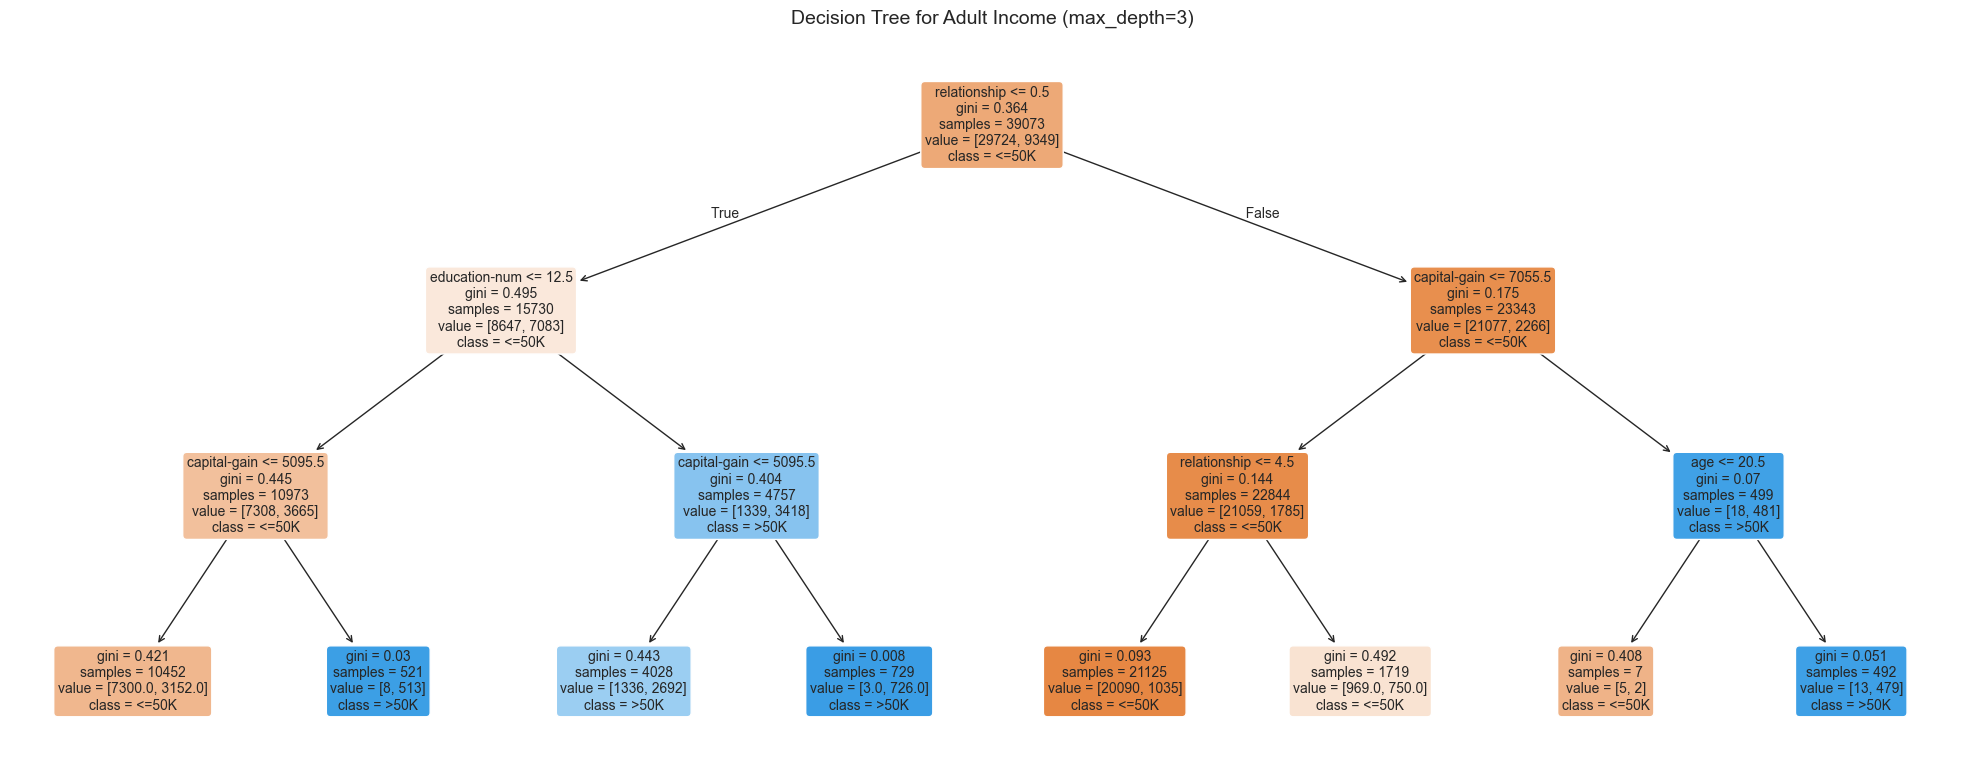

In [5]:
# ─── VISUALIZE THE TREE ─────────────────────────────────────────────────────────
# We use sklearn's plot_tree (works without any external installation)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=X_adult.columns.tolist(),
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title('Decision Tree for Adult Income (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()


### How to Read This Chart: The Decision Tree Diagram

This diagram shows the entire decision tree as a flowchart. Here is how to read every element:

**Each box (node) contains:**
- **The split condition** (top line, e.g., `marital-status <= 2.5`) — the yes/no question being asked at this node. If the condition is TRUE, go to the LEFT child. If FALSE, go to the RIGHT child.
- **gini** — the Gini impurity of the node. 0 = perfectly pure (all one class). 0.5 = maximally mixed (50/50). Lower is better.
- **samples** — how many training examples landed in this node.
- **value** — the count of each class in this node, e.g., `[300, 180]` means 300 earn ≤50K and 180 earn >50K.
- **class** — the prediction this node would make if it were a leaf (the majority class).

**Colors:**
- Nodes are colored by their dominant class. Darker color = higher purity (more one-sided).
- Orange tones = the tree predicts "≤50K". Blue tones = predicts ">50K".

**Root node (top):** The very first split — the single most informative question. For the Adult data this is often `marital-status`, `relationship`, or `capital-gain`, because these separate income levels strongly (e.g. married people and those with capital gains are far more likely to earn >50K).

**Leaf nodes (bottom row):** These are the terminal nodes — no more splits. Each leaf represents a final decision region, and its `class` line shows what the model predicts for any person that lands there.

**How to trace a prediction:**
> Imagine a 45-year-old married person with high capital gains. Start at the root, answer each condition (go LEFT if true, RIGHT if false), and continue until you reach a leaf. That leaf's class is the prediction.


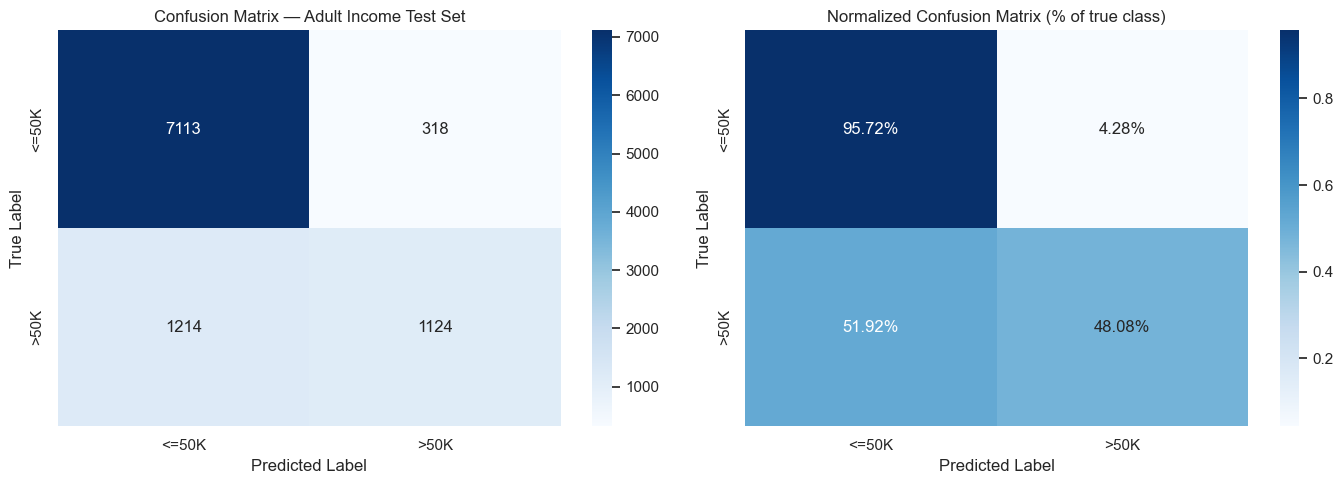


=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.85      0.96      0.90      7431
        >50K       0.78      0.48      0.59      2338

    accuracy                           0.84      9769
   macro avg       0.82      0.72      0.75      9769
weighted avg       0.84      0.84      0.83      9769



In [6]:
# ─── CONFUSION MATRIX ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_t, y_pred_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K'],
    ax=axes[0]
)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix — Adult Income Test Set')

# Normalized confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K'],
    ax=axes[1]
)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Normalized Confusion Matrix (% of true class)')

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test_t, y_pred_t, target_names=['<=50K', '>50K']))


### How to Read These Charts: Confusion Matrix

#### Left Chart: Raw Counts

The confusion matrix compares the model's predictions to the actual outcomes for every person in the test set. We treat `>50K` as the **positive** class.

- **Rows** = the actual (true) label
- **Columns** = what the model predicted
- **The 2x2 grid has four cells:**

| Cell | Name | Meaning |
|------|------|---------|
| Top-left | **True Negative (TN)** | Actually ≤50K, model correctly predicted ≤50K |
| Top-right | **False Positive (FP)** | Actually ≤50K, model incorrectly predicted >50K |
| Bottom-left | **False Negative (FN)** | Actually >50K, model incorrectly predicted ≤50K |
| Bottom-right | **True Positive (TP)** | Actually >50K, model correctly predicted >50K |

The diagonal cells (top-left and bottom-right) are **correct predictions**. The off-diagonal cells are **errors**.

#### Right Chart: Normalized (Percentages)

The normalized confusion matrix shows what **fraction of each true class** the model got right or wrong. This is more informative when the classes are imbalanced (which they are here — about three times as many people earn ≤50K as >50K).

- Top-left cell: "Of all the people who actually earn ≤50K, what % did the model correctly label as ≤50K?"
- Bottom-right cell: "Of all the people who actually earn >50K, what % did the model correctly label as >50K?"

#### Classification Report

- **Precision** = of all people the model said earn >50K, what fraction actually do?
- **Recall** = of all people who actually earn >50K, what fraction did the model catch?
- **F1-score** = harmonic mean of precision and recall — a single balanced measure
- **Support** = how many samples of each true class exist in the test set


---

## Step 5 — Feature Importance vs Permutation Importance

### What Is Feature Importance?

After training a decision tree, sklearn automatically calculates a score for each feature called **feature importance** (also called the Gini importance or Mean Decrease in Impurity).

It measures: "How much did this feature reduce the total impurity of the tree, summed across all nodes where it was used?"

A feature used at the root node — the very first split — contributes a lot, because it affects all training samples. A feature used only in deep leaf nodes contributes less.

### What Is Permutation Importance?

Permutation importance works differently. For each feature, it:
1. Takes the **trained model** and the **test set**
2. Randomly shuffles just that one feature (destroying its relationship with the target)
3. Measures how much the model's accuracy **drops**
4. If accuracy drops a lot → that feature was important. If it barely changes → the feature didn't matter much.

### Why Do They Sometimes Disagree?

Built-in feature importance has a well-known **bias toward high-cardinality features** — features with many unique values (like `capital-gain` or `age`). These features offer more possible split points, so the tree tends to use them more, inflating their apparent importance.

Permutation importance is measured on the **held-out test set**, so it reflects real predictive power on unseen data — making it more reliable in many situations.


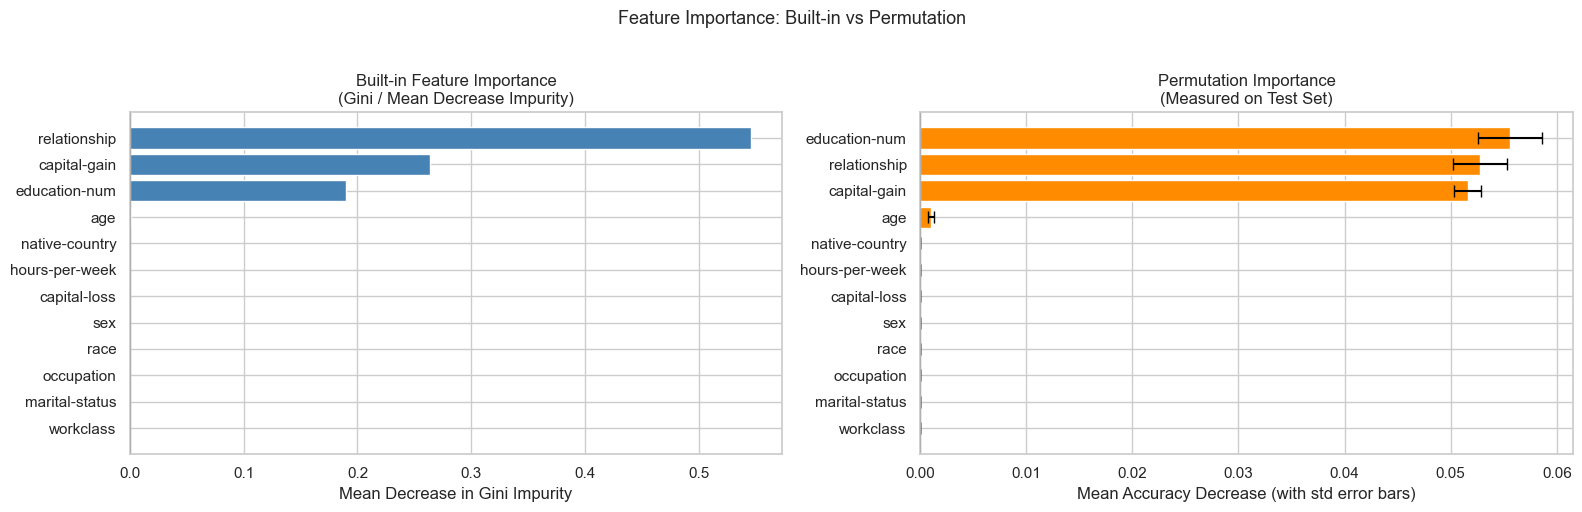

In [7]:
# ─── COMPUTE PERMUTATION IMPORTANCE ─────────────────────────────────────────────
perm_imp = permutation_importance(
    clf, X_test_t, y_test_t,
    n_repeats=30, random_state=42, scoring='accuracy'
)

# ─── BUILD DATAFRAMES FOR PLOTTING ──────────────────────────────────────────────
feat_names = X_adult.columns.tolist()

df_builtin = pd.DataFrame({
    'Feature': feat_names,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=True)

df_perm = pd.DataFrame({
    'Feature': feat_names,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=True)

# ─── PLOT BOTH SIDE BY SIDE ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Built-in Feature Importance
axes[0].barh(df_builtin['Feature'], df_builtin['Importance'], color='steelblue')
axes[0].set_xlabel('Mean Decrease in Gini Impurity')
axes[0].set_title('Built-in Feature Importance\n(Gini / Mean Decrease Impurity)')
axes[0].axvline(0, color='black', linewidth=0.8)

# Permutation Importance
axes[1].barh(
    df_perm['Feature'], df_perm['Importance'],
    xerr=df_perm['Std'], color='darkorange', ecolor='black', capsize=4
)
axes[1].set_xlabel('Mean Accuracy Decrease (with std error bars)')
axes[1].set_title('Permutation Importance\n(Measured on Test Set)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Feature Importance: Built-in vs Permutation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### How to Read This Chart: Feature Importance vs Permutation Importance

#### Left Chart: Built-in (Gini) Feature Importance

- **Each bar** represents one feature.
- **Bar length** = how much total Gini impurity that feature reduced across all nodes in the tree.
- **Longer bar = more important** according to this metric.
- Features not used by the tree at all have a bar of length 0.
- **Known limitation:** This metric is biased toward features with many unique values (like `capital-gain` or `age`) because they offer more split points. A feature might appear important here simply because it has a lot of thresholds to try, not because it is genuinely predictive.

#### Right Chart: Permutation Importance

- **Each bar** shows the average drop in test accuracy when that feature is randomly shuffled.
- **The error bars** show the standard deviation across 30 random shuffles — a wide error bar means the importance estimate is unstable.
- **Positive bar** = shuffling this feature hurts accuracy → the feature is important.
- **Near-zero or negative bar** = shuffling this feature barely changes accuracy → the feature is not important for real predictions.
- **Bars near or below 0** for some features can mean the model is actually slightly *better* when that feature is randomized — a sign that feature was causing slight overfitting.

#### Why They Differ — and Which to Trust

The two methods may rank features differently, especially for:
- **High-cardinality features** (many unique values): built-in inflates their importance; permutation is more honest.
- **Correlated features**: if two features are correlated, permutation importance may underestimate both (shuffling one hurts less because the other still carries similar information).

> **Rule of thumb:** For a first look, use built-in importance. For production feature selection or auditing a model, use permutation importance — it better reflects true predictive value on unseen data.


---

## Step 6 — Decision Boundary Visualization (2D Synthetic Data)

### Why Use Synthetic 2D Data?

The Adult dataset has 12 features — we cannot plot all of them at once. To **visualize decision boundaries**, we create a simple 2-feature synthetic dataset.

This lets us see exactly what the decision tree is doing in the input space: drawing **axis-aligned rectangular regions** and assigning one class to each region.

We train trees at four different maximum depths to show the effect of depth on the decision boundary:
- **Depth 1** ("stump"): single split, two regions — classic underfitting
- **Depth 3**: balanced — captures the main structure without too many regions
- **Depth 5**: starts to show more complex boundaries
- **Unlimited depth**: a deep tree that fits the training data perfectly — classic overfitting


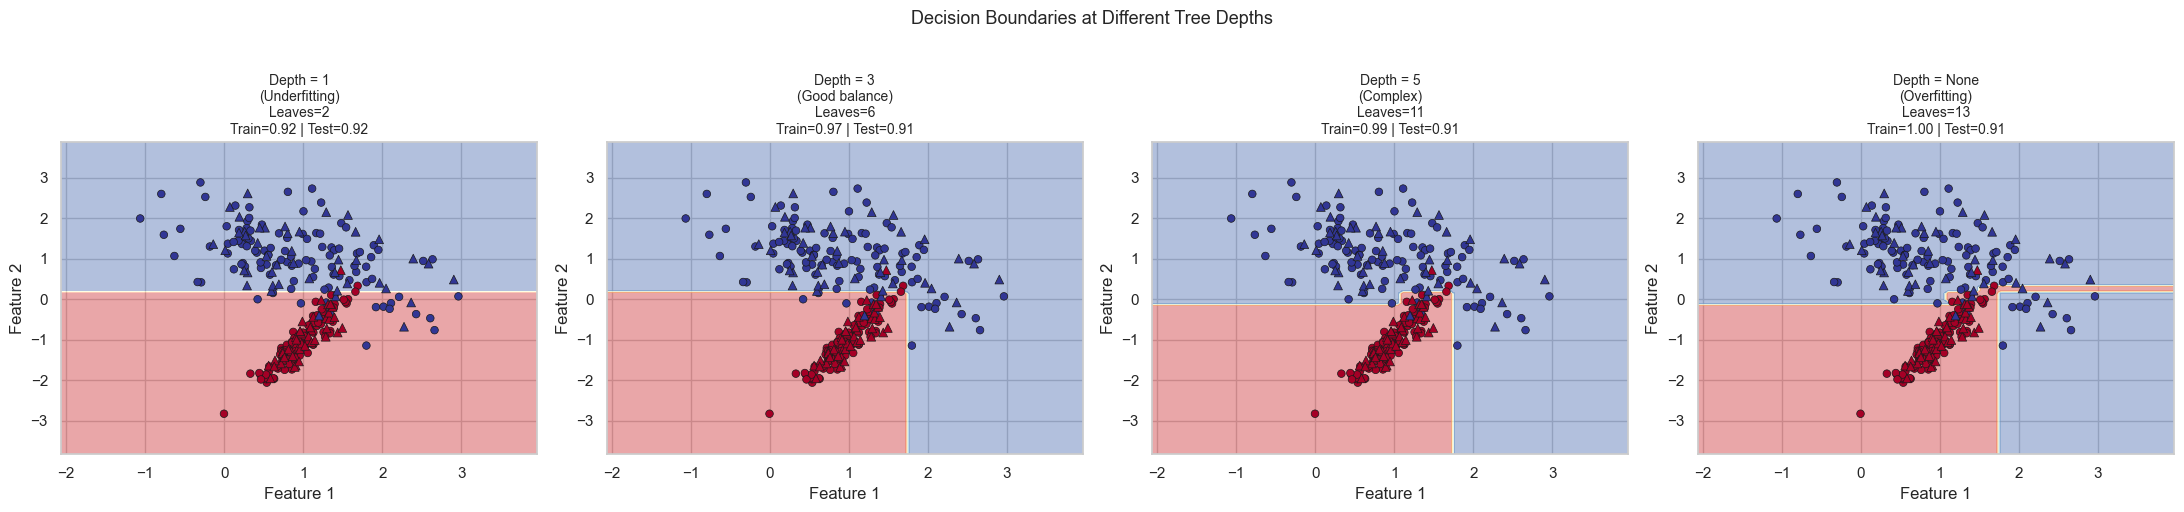

In [8]:
# Generate a 2D synthetic classification dataset
X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1,
    random_state=42
)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.3, random_state=42
)

# Train trees at different depths
depths = [1, 3, 5, None]
depth_labels = ['Depth = 1\n(Underfitting)', 'Depth = 3\n(Good balance)', 'Depth = 5\n(Complex)', 'Depth = None\n(Overfitting)']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, depth, label in zip(axes, depths, depth_labels):
    clf_2d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_2d.fit(X_train_2d, y_train_2d)
    
    train_score = clf_2d.score(X_train_2d, y_train_2d)
    test_score = clf_2d.score(X_test_2d, y_test_2d)
    n_leaves = clf_2d.get_n_leaves()
    
    # Decision boundary
    DecisionBoundaryDisplay.from_estimator(
        clf_2d, X_2d, alpha=0.4, ax=ax,
        response_method='predict',
        cmap=plt.cm.RdYlBu
    )
    
    # Scatter training points
    scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                         c=y_train_2d, cmap=plt.cm.RdYlBu,
                         edgecolors='k', s=30, linewidths=0.5, label='Train')
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
               c=y_test_2d, cmap=plt.cm.RdYlBu,
               marker='^', edgecolors='k', s=40, linewidths=0.5, label='Test')
    
    actual_depth = clf_2d.get_depth() if depth is None else depth
    ax.set_title(f'{label}\nLeaves={n_leaves}\nTrain={train_score:.2f} | Test={test_score:.2f}',
                 fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Decision Boundaries at Different Tree Depths', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### How to Read This Chart: Decision Boundaries at Different Depths

Each subplot shows a **2D view of how the decision tree divides the feature space**.

**What you are looking at:**
- The **background color** is the decision region — all points in a red/blue/yellow region get the same predicted class.
- **Circles** are training points; **triangles** are test points.
- The **color of each point** (red or blue) is its true class.
- A correctly classified point has the same color as its background region. A misclassified point does not.
- **The boundaries are always axis-aligned** (horizontal or vertical lines) — this is the hallmark of decision trees. They can only make cuts that are parallel to the feature axes.

**Reading each subplot:**

**Depth 1 (Underfitting):** A single vertical or horizontal cut splits the entire space in two. Very simple, but misses a lot of structure in the data. Train and test accuracy are both low. This is a classic **underfit** model — too simple to learn the data.

**Depth 3 (Good balance):** The boundary has 8 or fewer rectangular regions. It captures the broad structure of the data without going into extreme detail. Train accuracy is higher, and test accuracy should be close — indicating **good generalization**.

**Depth 5 (Complex):** The boundary is getting intricate — many small rectangular regions. Train accuracy keeps going up, but test accuracy may start to plateau or even drop slightly. Some of these small regions are picking up noise.

**Unlimited Depth (Overfitting):** The tree keeps splitting until every training point is correctly classified. The boundary is jagged and complex, with tiny isolated regions for individual points. Train accuracy is 100%, but test accuracy is **significantly lower** — the model has memorized the training data instead of learning the underlying pattern. This is **overfitting**.

> **Key visual insight:** The rectangular-region structure of decision trees means they cannot model smooth curved boundaries efficiently. A gentle circular decision boundary would require hundreds of tiny rectangles to approximate.

---

## Step 7 — The Bias-Variance Tradeoff (THE KEY SECTION)

### This Is the Most Important Concept in Machine Learning

The bias-variance tradeoff describes a fundamental tension in every machine learning model:

**Bias** = error from wrong assumptions. A highly biased model is too simple — it misses real patterns in the data. This is called **underfitting**.

**Variance** = error from sensitivity to small fluctuations in training data. A high-variance model is too complex — it fits the training data too specifically, including its random noise. This is called **overfitting**.

**The tradeoff:**
- Making a model more complex reduces bias (it can capture more patterns)
- But increasing complexity also increases variance (it starts fitting noise)
- The goal is to find the **sweet spot** where total error is minimized

For decision trees, **depth is the complexity knob:**
- **Small depth → high bias (underfitting):** The tree can't capture the real patterns
- **Large depth → high variance (overfitting):** The tree memorizes the training data
- **Right depth → balanced:** Good generalization to new data

The plot below shows this tradeoff visually.

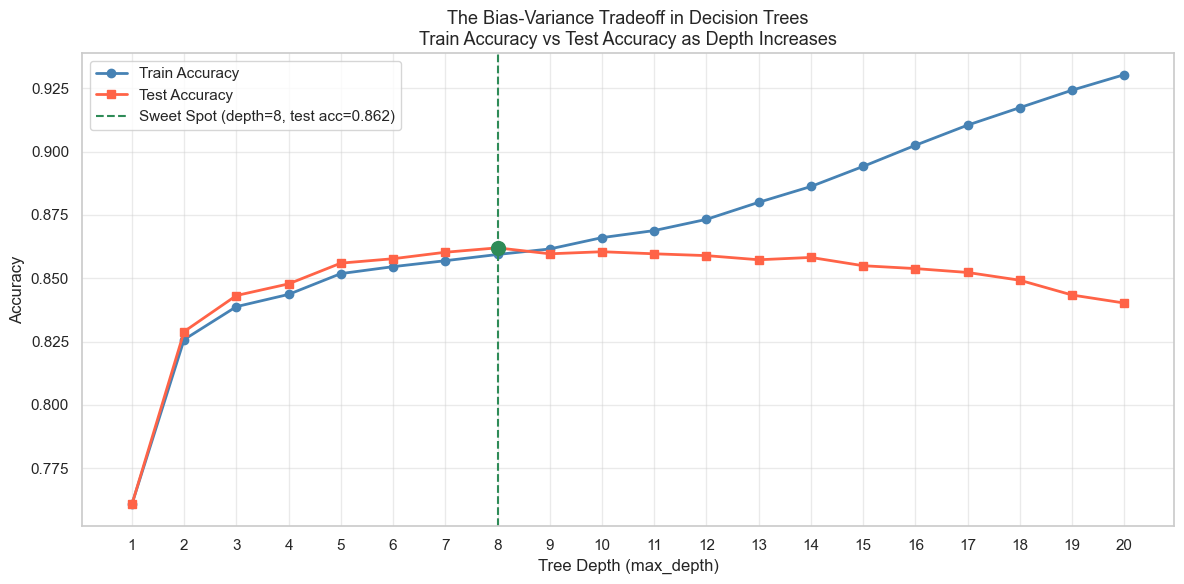


Best test accuracy: 0.8620 at max_depth = 8
Train accuracy at that depth: 0.8594


In [9]:
# Train trees at depths 1 through 20 and record train/test accuracy
max_depths = list(range(1, 21))
train_accs = []
test_accs = []

for d in max_depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train_t, y_train_t)
    train_accs.append(tree.score(X_train_t, y_train_t))
    test_accs.append(tree.score(X_test_t, y_test_t))

# Find the sweet spot (best test accuracy)
best_depth = max_depths[np.argmax(test_accs)]
best_test_acc = max(test_accs)

# ─── PLOT ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(max_depths, train_accs, 'o-', color='steelblue', linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(max_depths, test_accs, 's-', color='tomato', linewidth=2, markersize=6, label='Test Accuracy')

# Mark the sweet spot
plt.axvline(x=best_depth, color='seagreen', linestyle='--', linewidth=1.5,
            label=f'Sweet Spot (depth={best_depth}, test acc={best_test_acc:.3f})')
plt.scatter([best_depth], [best_test_acc], color='seagreen', zorder=5, s=100)

# Annotations
plt.annotate('← High Bias\n(Underfitting)',
             xy=(2, 0.72), fontsize=10, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray'),
             xytext=(2, 0.68))
plt.annotate('High Variance →\n(Overfitting)',
             xy=(15, 0.75), fontsize=10, color='gray',
             ha='right')

plt.xlabel('Tree Depth (max_depth)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('The Bias-Variance Tradeoff in Decision Trees\nTrain Accuracy vs Test Accuracy as Depth Increases', fontsize=13)
plt.xticks(max_depths)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nBest test accuracy: {best_test_acc:.4f} at max_depth = {best_depth}")
print(f"Train accuracy at that depth: {train_accs[best_depth-1]:.4f}")

### How to Read This Chart: The Bias-Variance Tradeoff

This is **the single most important chart in supervised machine learning**. Every algorithm has a version of this chart. Understanding it is the key to building good models.

**The two lines:**
- **Blue line (Train Accuracy):** How well the model fits the data it was trained on. It always goes up or stays flat as depth increases — a deeper tree can always fit the training data better.
- **Red line (Test Accuracy):** How well the model predicts on data it has NEVER seen. This is the only line that matters for real-world performance.

**Three regions of the chart:**

**1. Left side (shallow trees) — HIGH BIAS (Underfitting):**
Both lines are low. The tree is too simple. It's making wrong assumptions — for example, a depth-1 tree can only ask one question. It misses the real patterns in the data. Train accuracy is low, test accuracy is also low.

**2. Middle (the sweet spot):**
The green dashed line marks the depth with the best test accuracy. Train accuracy is noticeably above test accuracy, but test accuracy is at its peak. The model has learned the real patterns without memorizing noise. This is where you want to be.

**3. Right side (deep trees) — HIGH VARIANCE (Overfitting):**
Train accuracy continues rising toward 100%. But test accuracy starts DROPPING. The tree is memorizing specific training examples — including random noise and outliers — that don't generalize. A large gap between the blue and red lines is the signature of overfitting.

**The golden rule:**
> **Always trust test accuracy, never train accuracy.** A model with 99% train accuracy and 75% test accuracy is NOT a good model — it has just memorized the training data.

**Why does test accuracy eventually drop?**
Because the deep tree creates very small, specific decision regions — sometimes containing only one or two training points. These regions perfectly fit the training data but are essentially random noise. When a new test point falls into that region, it gets the wrong prediction.

**How to apply this in practice:**
1. Train the model at many depths
2. Plot train and test accuracy (or use cross-validation)
3. Pick the depth where test accuracy is maximized
4. Watch for a large train-test gap — that is overfitting

---

## Step 8 — Overfitting Demonstration

The bias-variance chart told the story in numbers. Now let's see it concretely by comparing:
1. A tree with **no depth limit** (maximum overfitting)
2. The same tree after applying **pruning constraints**

This section shows you exactly how much damage overfitting does, and how easy it is to fix with the right hyperparameters.

In [10]:
# ─── UNLIMITED DEPTH TREE ────────────────────────────────────────────────────────
clf_full = DecisionTreeClassifier(random_state=42)  # No max_depth limit
clf_full.fit(X_train_t, y_train_t)

full_train = clf_full.score(X_train_t, y_train_t)
full_test = clf_full.score(X_test_t, y_test_t)

print("=== Unlimited Depth Tree (Overfitted) ===")
print(f"  Max Depth  : {clf_full.get_depth()}")
print(f"  Num Leaves : {clf_full.get_n_leaves()}")
print(f"  Train Acc  : {full_train:.4f}")
print(f"  Test  Acc  : {full_test:.4f}")
print(f"  Train-Test Gap: {full_train - full_test:.4f}")

print()

# ─── PRUNED TREE ─────────────────────────────────────────────────────────────────
clf_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,   # each leaf must have at least 10 training samples
    random_state=42
)
clf_pruned.fit(X_train_t, y_train_t)

pruned_train = clf_pruned.score(X_train_t, y_train_t)
pruned_test = clf_pruned.score(X_test_t, y_test_t)

print("=== Pruned Tree (max_depth=4, min_samples_leaf=10) ===")
print(f"  Max Depth  : {clf_pruned.get_depth()}")
print(f"  Num Leaves : {clf_pruned.get_n_leaves()}")
print(f"  Train Acc  : {pruned_train:.4f}")
print(f"  Test  Acc  : {pruned_test:.4f}")
print(f"  Train-Test Gap: {pruned_train - pruned_test:.4f}")

=== Unlimited Depth Tree (Overfitted) ===
  Max Depth  : 43
  Num Leaves : 7053
  Train Acc  : 0.9737
  Test  Acc  : 0.8223
  Train-Test Gap: 0.1514

=== Pruned Tree (max_depth=4, min_samples_leaf=10) ===
  Max Depth  : 4
  Num Leaves : 15
  Train Acc  : 0.8435
  Test  Acc  : 0.8478
  Train-Test Gap: -0.0043


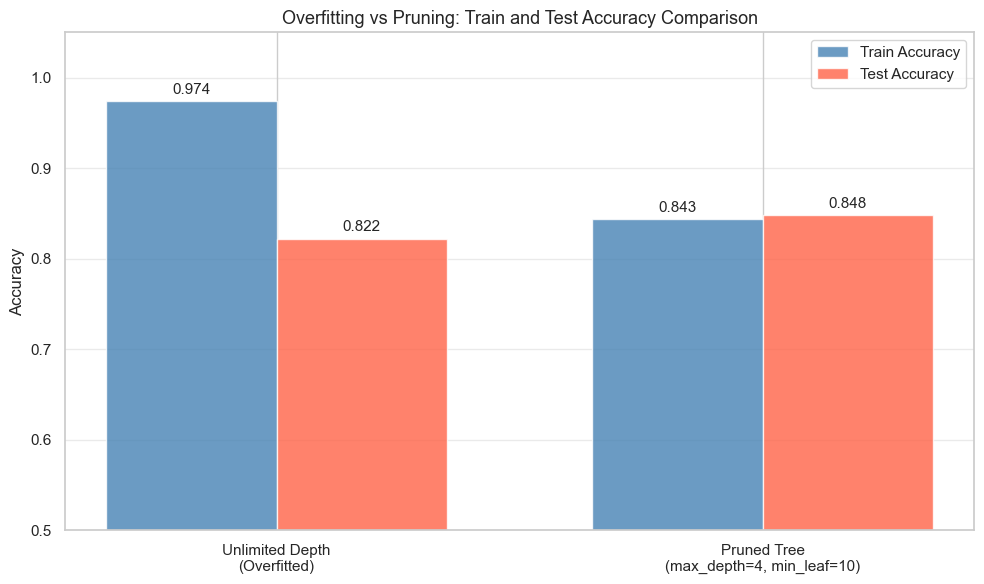


Pruning reduced the train-test gap from 0.1514 to -0.0043
Test accuracy improved by 0.0255 after pruning.


In [11]:
# ─── SIDE BY SIDE BAR CHART ─────────────────────────────────────────────────────
models = ['Unlimited Depth\n(Overfitted)', 'Pruned Tree\n(max_depth=4, min_leaf=10)']
train_scores = [full_train, pruned_train]
test_scores = [full_test, pruned_test]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', color='tomato', alpha=0.8)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting vs Pruning: Train and Test Accuracy Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nPruning reduced the train-test gap from {full_train-full_test:.4f} to {pruned_train-pruned_test:.4f}")
print(f"Test accuracy improved by {pruned_test - full_test:.4f} after pruning.")

### Understanding This Result

**Unlimited depth tree:**
- 100% train accuracy — it memorized every training example perfectly
- Significantly lower test accuracy — it fails on new data it has never seen
- The train-test gap is large — the signature of severe overfitting
- The tree is very deep with many leaves — each leaf may contain just one or two training samples

**Pruned tree (max_depth=4, min_samples_leaf=10):**
- Train accuracy drops (the model is no longer memorizing)
- But test accuracy IMPROVES — because the model learned real patterns, not noise
- Smaller train-test gap — better generalization
- Far fewer leaves — each represents a meaningful, generalizable pattern

**What `min_samples_leaf=10` does:**
It prevents the tree from creating any leaf with fewer than 10 training samples. This stops the tree from creating tiny, noise-specific regions for just one or two unusual training points. Any region with fewer than 10 samples is treated as not statistically reliable enough to split further.

> **Practical rule:** Before using a decision tree in production, always set at least one pruning parameter. An unlimited depth tree is almost always overfit.

---

## Step 9 — Cost-Complexity Pruning (ccp_alpha)

### What Is Cost-Complexity Pruning?

Setting `max_depth` and `min_samples_leaf` manually is somewhat arbitrary — you have to guess good values. **Cost-complexity pruning** provides a principled, data-driven approach.

The idea: every leaf in the tree adds complexity (variance risk). Cost-complexity pruning adds a **complexity penalty** to the tree's training loss:

$$\text{Total Cost} = \text{Impurity} + \alpha \times \text{Number of Leaves}$$

Where:
- **Impurity** = total Gini impurity of all leaves (the "error" on training data)
- **α (ccp_alpha)** = the penalty per leaf
- **Number of Leaves** = complexity of the tree

**When α = 0:** No penalty → grows the full tree → maximum overfitting  
**When α is large:** Heavy penalty for leaves → tree gets pruned aggressively → underfitting  
**Optimal α:** Found by plotting test accuracy vs α and picking the best value

sklearn's `cost_complexity_pruning_path` automatically computes all the α values at which the tree structure changes, giving us a complete picture of the pruning path.

In [12]:
# ─── COMPUTE THE PRUNING PATH ────────────────────────────────────────────────────
clf_path = DecisionTreeClassifier(random_state=42)
path = clf_path.cost_complexity_pruning_path(X_train_t, y_train_t)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of alpha values in pruning path: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas[0]:.6f} to {ccp_alphas[-1]:.6f}")

# ─── TRAIN A TREE FOR EACH ALPHA ─────────────────────────────────────────────────
# Remove the last alpha (creates a trivial single-node tree)
ccp_alphas_trimmed = ccp_alphas[:-1]

# On a large dataset the pruning path can contain thousands of alphas; fitting a full
# tree for each would be slow. Sample a representative subset for the plot.
if len(ccp_alphas_trimmed) > 40:
    idx = np.linspace(0, len(ccp_alphas_trimmed) - 1, 40).astype(int)
    ccp_alphas_trimmed = ccp_alphas_trimmed[idx]

clfs_ccp = []
for alpha in ccp_alphas_trimmed:
    clf_ccp = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf_ccp.fit(X_train_t, y_train_t)
    clfs_ccp.append(clf_ccp)

# Collect metrics
train_scores_ccp = [c.score(X_train_t, y_train_t) for c in clfs_ccp]
test_scores_ccp = [c.score(X_test_t, y_test_t) for c in clfs_ccp]
n_leaves_ccp = [c.get_n_leaves() for c in clfs_ccp]
n_depth_ccp = [c.get_depth() for c in clfs_ccp]

print(f"\nNumber of trees evaluated: {len(clfs_ccp)}")
print(f"Leaves range from {max(n_leaves_ccp)} (small alpha) down to {min(n_leaves_ccp)} (large alpha)")


Number of alpha values in pruning path: 2672
Alpha range: 0.000000 to 0.060011



Number of trees evaluated: 40
Leaves range from 7053 (small alpha) down to 2 (large alpha)


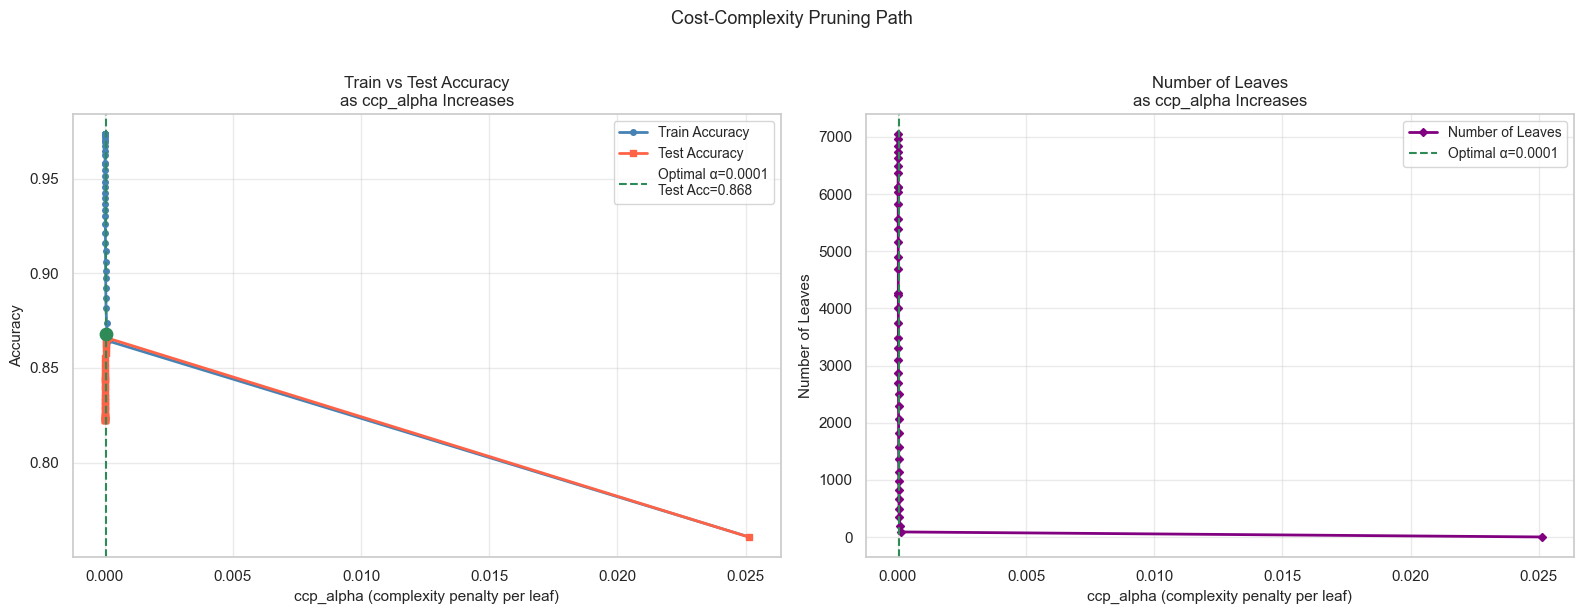


Optimal ccp_alpha: 0.00005
Tree at optimal alpha: 346 leaves, depth=21
Train Accuracy: 0.8815 | Test Accuracy: 0.8682


In [13]:
# ─── PLOT: Train and Test Accuracy vs ccp_alpha ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy vs alpha
axes[0].plot(ccp_alphas_trimmed, train_scores_ccp, 'o-', color='steelblue',
             linewidth=2, markersize=4, label='Train Accuracy')
axes[0].plot(ccp_alphas_trimmed, test_scores_ccp, 's-', color='tomato',
             linewidth=2, markersize=4, label='Test Accuracy')

# Find optimal alpha
best_idx = np.argmax(test_scores_ccp)
best_alpha = ccp_alphas_trimmed[best_idx]
best_score = test_scores_ccp[best_idx]

axes[0].axvline(x=best_alpha, color='seagreen', linestyle='--', linewidth=1.5,
                label=f'Optimal α={best_alpha:.4f}\nTest Acc={best_score:.3f}')
axes[0].scatter([best_alpha], [best_score], color='seagreen', zorder=5, s=80)
axes[0].set_xlabel('ccp_alpha (complexity penalty per leaf)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Train vs Test Accuracy\nas ccp_alpha Increases', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# Number of leaves vs alpha
axes[1].plot(ccp_alphas_trimmed, n_leaves_ccp, 'D-', color='purple',
             linewidth=2, markersize=4, label='Number of Leaves')
axes[1].axvline(x=best_alpha, color='seagreen', linestyle='--', linewidth=1.5,
                label=f'Optimal α={best_alpha:.4f}')
axes[1].set_xlabel('ccp_alpha (complexity penalty per leaf)', fontsize=11)
axes[1].set_ylabel('Number of Leaves', fontsize=11)
axes[1].set_title('Number of Leaves\nas ccp_alpha Increases', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Cost-Complexity Pruning Path', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nOptimal ccp_alpha: {best_alpha:.5f}")
print(f"Tree at optimal alpha: {n_leaves_ccp[best_idx]} leaves, depth={n_depth_ccp[best_idx]}")
print(f"Train Accuracy: {train_scores_ccp[best_idx]:.4f} | Test Accuracy: {best_score:.4f}")

### How to Read This Chart: The Pruning Path

#### Left Chart: Accuracy vs ccp_alpha

- **x-axis:** ccp_alpha — the penalty applied per leaf. Higher = more aggressive pruning.
- **y-axis:** Accuracy on train (blue) and test (red) sets.
- **What happens as α increases from left to right:**
  - At α = 0 (far left): Full tree, maximum overfitting. Train accuracy is high, test accuracy may be lower.
  - As α increases: The tree gets pruned — leaves are removed. Train accuracy drops (the model fits training data less perfectly).
  - The test accuracy first rises (as we remove noise-fitting leaves) then falls (as we start removing genuinely useful leaves).
  - The green dashed line marks the **sweet spot** — the α that gives the highest test accuracy.
- **Large values of α** (right side): The tree has been pruned to almost nothing — just a stump. Both train and test accuracy are low (underfitting).

#### Right Chart: Number of Leaves vs ccp_alpha

- Shows how aggressively pruning reduces the tree size.
- At α = 0: The full tree with all its leaves.
- As α increases: Leaves are pruned off — the tree shrinks.
- The step-function shape reflects that pruning removes entire subtrees at once, not one leaf at a time.
- The green line shows the optimal α — the tree at this point has enough leaves to capture real patterns, but not so many that it's memorizing noise.

#### How to Use This to Pick ccp_alpha

1. Run `cost_complexity_pruning_path` on your training data
2. Train a tree for each α value
3. Evaluate each tree on a validation set (or use cross-validation)
4. Pick the α with the best validation performance
5. Train your final tree with that α on the full training data

> **This is the principled, data-driven way to prune** — no guessing at max_depth values.

---

## Step 10 — Decision Tree for Regression (Ames Housing)

### Trees Are Not Just for Classification

A `DecisionTreeRegressor` works the same way as the classifier — recursive binary splitting — but uses different criteria:

- **Split criterion:** Instead of Gini or Entropy, the regressor minimizes **Mean Squared Error (MSE)** within each node
- **Leaf prediction:** Instead of majority class, the leaf predicts the **mean target value** of all training samples that fell there

Everything else — depth control, pruning, feature importance, overfitting — works identically.

We will:
1. Train a `DecisionTreeRegressor` on Ames Housing
2. Plot Actual vs Predicted on the test set
3. Show how RMSE changes with max_depth (the same bias-variance tradeoff, now for regression)


In [14]:
# ─── TRAIN A REGRESSION TREE ─────────────────────────────────────────────────────
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train_h, y_train_h)

y_pred_h = reg.predict(X_test_h)

train_rmse = np.sqrt(mean_squared_error(y_train_h, reg.predict(X_train_h)))
test_rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))

print("=== Decision Tree Regressor (max_depth=5) ===")
print(f"Train RMSE : {train_rmse:,.0f}")
print(f"Test  RMSE : {test_rmse:,.0f}")
print(f"Tree Depth : {reg.get_depth()}")
print(f"Num Leaves : {reg.get_n_leaves()}")
print()
print(f"Recall: RMSE is in units of the target. Here, the target is the house sale price in US dollars.")
print(f"A test RMSE of {test_rmse:,.0f} means predictions are off by about ${test_rmse:,.0f} on average.")


=== Decision Tree Regressor (max_depth=5) ===
Train RMSE : 28,558
Test  RMSE : 38,648
Tree Depth : 5
Num Leaves : 30

Recall: RMSE is in units of the target. Here, the target is the house sale price in US dollars.
A test RMSE of 38,648 means predictions are off by about $38,648 on average.


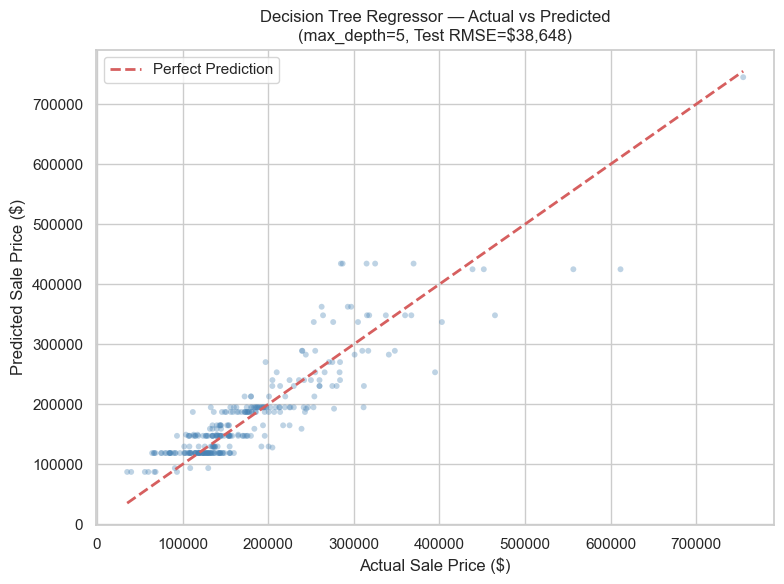

In [15]:
# ─── ACTUAL vs PREDICTED SCATTER PLOT ───────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.35, color='steelblue', edgecolors='none', s=18)
min_val = min(y_test_h.min(), y_pred_h.min())
max_val = max(y_test_h.max(), y_pred_h.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title(f'Decision Tree Regressor — Actual vs Predicted\n(max_depth=5, Test RMSE=${test_rmse:,.0f})', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### How to Read This Chart: Regression Tree Actual vs Predicted

This scatter plot compares the model's predictions to the true sale prices on the test set.

- **Each dot** is one house (one row in the test set). Its x-position is the **actual sale price**, and its y-position is the **model's prediction**.
- **The red dashed line** is the "perfect prediction" diagonal. If every prediction were exact, all dots would sit on this line.
- **Dots close to the red line** = good predictions.
- **Dots far from the red line** = large prediction errors.

**What to notice about a regression tree's predictions:**
- Unlike linear regression, which produces a smooth cloud, the regression tree's predictions form **distinct horizontal bands**. This is because each leaf predicts a single constant value (the mean of samples in that leaf). The number of distinct bands equals the number of leaves.
- With depth=5, the tree has many leaves and thus many prediction levels — you can see the banding pattern where multiple actual values map to the same predicted value.
- The **spread around the diagonal** shows the prediction error. A tighter spread = lower RMSE = better model.
- **The most expensive houses tend to be under-predicted** (dots below the line at the far right). A tree can never predict a value higher than the largest average it saw in training, so it cannot extrapolate to record-breaking prices.


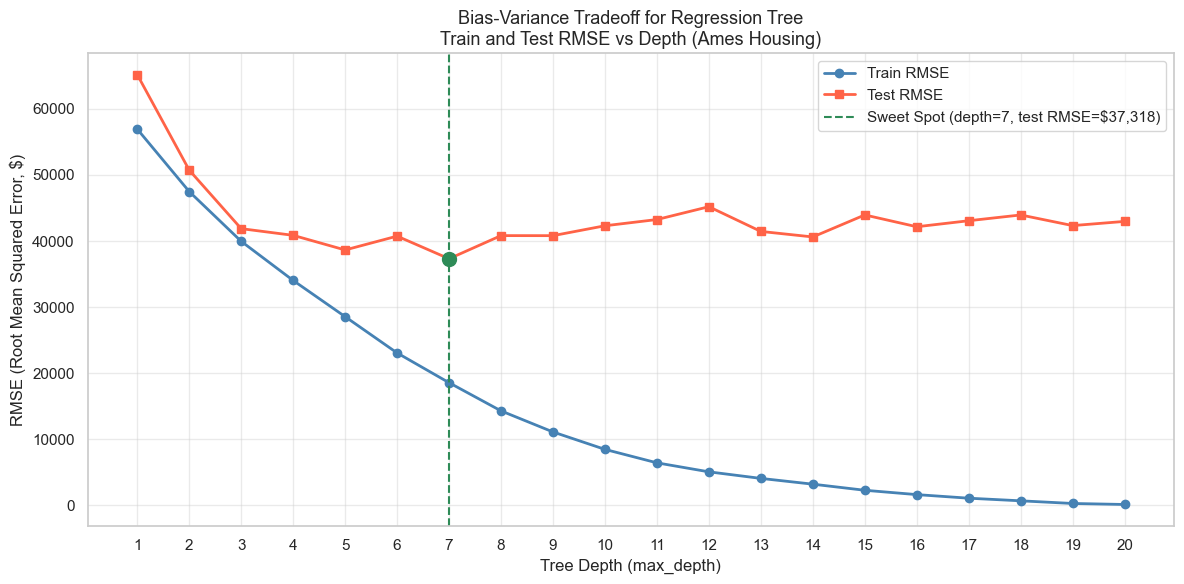


Best test RMSE: $37,318 at max_depth = 7
Unlimited tree test RMSE would be higher due to overfitting.


In [16]:
# ─── RMSE vs DEPTH PLOT ─────────────────────────────────────────────────────────
depths_r = list(range(1, 21))
train_rmses = []
test_rmses = []

for d in depths_r:
    reg_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg_d.fit(X_train_h, y_train_h)
    train_rmses.append(np.sqrt(mean_squared_error(y_train_h, reg_d.predict(X_train_h))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test_h, reg_d.predict(X_test_h))))

best_depth_r = depths_r[np.argmin(test_rmses)]
best_rmse_r = min(test_rmses)

plt.figure(figsize=(12, 6))
plt.plot(depths_r, train_rmses, 'o-', color='steelblue', linewidth=2, markersize=6, label='Train RMSE')
plt.plot(depths_r, test_rmses, 's-', color='tomato', linewidth=2, markersize=6, label='Test RMSE')
plt.axvline(x=best_depth_r, color='seagreen', linestyle='--', linewidth=1.5,
            label=f'Sweet Spot (depth={best_depth_r}, test RMSE=${best_rmse_r:,.0f})')
plt.scatter([best_depth_r], [best_rmse_r], color='seagreen', zorder=5, s=100)

plt.xlabel('Tree Depth (max_depth)', fontsize=12)
plt.ylabel('RMSE (Root Mean Squared Error, $)', fontsize=12)
plt.title('Bias-Variance Tradeoff for Regression Tree\nTrain and Test RMSE vs Depth (Ames Housing)', fontsize=13)
plt.xticks(depths_r)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nBest test RMSE: ${best_rmse_r:,.0f} at max_depth = {best_depth_r}")
print(f"Unlimited tree test RMSE would be higher due to overfitting.")


### How to Read This Chart: Regression Tree Train RMSE vs Test RMSE

Same bias-variance tradeoff concept as in Section 7, but now applied to regression.

- **RMSE (lower is better):** Root Mean Squared Error — the average prediction error in the same units as the target (house sale price in US dollars)
- **Blue line (Train RMSE):** Always decreases as depth grows — deeper tree fits training data better
- **Red line (Test RMSE):** Decreases first, then INCREASES as the tree starts overfitting

**Key observations:**
- At shallow depths (left), both lines are high — **underfitting** (the tree can't capture the complexity of house prices)
- At the green dashed line, test RMSE is minimized — this is the **sweet spot**
- At deep depths (right), train RMSE continues falling while test RMSE rises — classic **overfitting** pattern

> **The pattern is the same for classification and regression.** The bias-variance tradeoff is universal — it appears in every supervised learning algorithm. What changes is the metric (accuracy vs RMSE), not the shape of the tradeoff.


---

## Step 11 — Time and Memory Complexity

### Theoretical Complexity

Understanding how a decision tree scales with data size is important for deploying it in production.

| Operation | Complexity | Notes |
|-----------|-----------|-------|
| **Training (fit)** | O(n · log(n) · d) | n = samples, d = features. At each node, sort each feature to find best split. |
| **Prediction (predict)** | O(depth) | Follow one path from root to leaf. Very fast. |
| **Memory (model size)** | O(leaves) | Each leaf stores its prediction. Deep trees have many leaves. |

**What this means in practice:**
- Training is the expensive part, but it's still efficient — sorting n items takes O(n log n), and we do this for each of d features at each level
- Prediction is extremely fast — just traverse the tree from root to leaf (depth steps)
- Memory grows with the number of leaves, which can be exponential in depth but is controlled by pruning

**Comparison to other models:**

| Model | Train | Predict | Memory |
|-------|-------|---------|--------|
| Decision Tree | O(n log n · d) | O(depth) | O(leaves) |
| Linear Regression | O(n · d²) | O(d) | O(d) |
| KNN | O(1) (lazy) | O(n · d) | O(n · d) |
| SVM | O(n² to n³) | O(sv · d) | O(sv) |
| Random Forest | O(n log n · d · T) | O(depth · T) | O(leaves · T) |

*sv = number of support vectors, T = number of trees in forest*

Decision trees have **very fast prediction** — this makes them ideal when you need real-time inference at scale.

In [17]:
# ─── EMPIRICAL TIMING ───────────────────────────────────────────────────────────
import timeit

print("=" * 60)
print("EMPIRICAL TIMING COMPARISON")
print("=" * 60)

# ── Adult Income (classification) ────────────────────────────────────────────
clf_time = DecisionTreeClassifier(max_depth=5, random_state=42)

# Training time
n_runs = 20
start = time.perf_counter()
for _ in range(n_runs):
    clf_time.fit(X_train_t, y_train_t)
end = time.perf_counter()
train_time_t = (end - start) / n_runs * 1000  # ms

clf_time.fit(X_train_t, y_train_t)  # fit once for predict timing
start = time.perf_counter()
for _ in range(n_runs):
    clf_time.predict(X_test_t)
end = time.perf_counter()
predict_time_t = (end - start) / n_runs * 1000  # ms

print(f"\nAdult Income (Classification)")
print(f"  Training samples : {X_train_t.shape[0]}")
print(f"  Features         : {X_train_t.shape[1]}")
print(f"  Avg Train Time   : {train_time_t:.3f} ms  (over {n_runs} runs)")
print(f"  Avg Predict Time : {predict_time_t:.3f} ms  (over {n_runs} runs, {X_test_t.shape[0]} samples)")

# ── Ames Housing (regression) ────────────────────────────────────────────────
reg_time = DecisionTreeRegressor(max_depth=5, random_state=42)

start = time.perf_counter()
for _ in range(n_runs):
    reg_time.fit(X_train_h, y_train_h)
end = time.perf_counter()
train_time_h = (end - start) / n_runs * 1000

reg_time.fit(X_train_h, y_train_h)
start = time.perf_counter()
for _ in range(n_runs):
    reg_time.predict(X_test_h)
end = time.perf_counter()
predict_time_h = (end - start) / n_runs * 1000

print(f"\nAmes Housing (Regression)")
print(f"  Training samples : {X_train_h.shape[0]}")
print(f"  Features         : {X_train_h.shape[1]}")
print(f"  Avg Train Time   : {train_time_h:.3f} ms  (over {n_runs} runs)")
print(f"  Avg Predict Time : {predict_time_h:.3f} ms  (over {n_runs} runs, {X_test_h.shape[0]} samples)")

big_name = 'Adult' if X_train_t.shape[0] > X_train_h.shape[0] else 'Ames'
ratio_n = max(X_train_t.shape[0], X_train_h.shape[0]) / min(X_train_t.shape[0], X_train_h.shape[0])
print(f"\n{big_name} is the larger dataset (~{ratio_n:.0f}x more rows).")
print(f"Training time tracks dataset size — roughly O(n log n · d) scaling as expected.")


EMPIRICAL TIMING COMPARISON



Adult Income (Classification)
  Training samples : 39073
  Features         : 12
  Avg Train Time   : 66.880 ms  (over 20 runs)
  Avg Predict Time : 6.177 ms  (over 20 runs, 9769 samples)



Ames Housing (Regression)
  Training samples : 1168
  Features         : 79
  Avg Train Time   : 22.816 ms  (over 20 runs)
  Avg Predict Time : 4.912 ms  (over 20 runs, 292 samples)

Adult is the larger dataset (~33x more rows).
Training time tracks dataset size — roughly O(n log n · d) scaling as expected.


---

## Step 12 — Summary and Key Takeaways

### What We Learned

In this notebook, we covered decision trees from first principles to practical application. Here is a consolidated summary.

---

### When to Use Decision Trees

Decision trees are a good first choice when:

- **Interpretability is required** — you need to explain *why* the model made a specific prediction (e.g., for regulatory compliance, medical diagnosis support, or business rules)
- **Mixed data types** — trees handle numeric and categorical features natively without needing separate preprocessing
- **No feature scaling needed** — unlike linear models, SVMs, or KNN, you can skip the StandardScaler step entirely
- **Fast prototyping** — a decision tree is quick to train, quick to predict, and its output is human-readable
- **Non-linear relationships** — trees can model complex non-linear patterns without manual feature engineering

---

### Pros and Cons Table

| Aspect | Pros | Cons |
|--------|------|------|
| **Interpretability** | Highly interpretable — the full decision process can be visualized and explained | Deep trees become hard to read |
| **Data preprocessing** | No scaling needed. Handles missing values in some implementations. | Sensitive to outliers — one extreme point can change a split |
| **Feature types** | Works natively with numeric AND categorical features | Categorical features must still be encoded in sklearn |
| **Non-linearity** | Captures complex non-linear patterns via rectangular splits | Can only make axis-aligned cuts — diagonal boundaries require many nodes |
| **Overfitting** | Easy to control with depth and leaf size constraints | Strongly prone to overfitting without pruning — unlimited trees memorize training data |
| **Speed** | Very fast to predict (O(depth) per sample) | Training can be slow for very large datasets |
| **Stability** | Deterministic given a fixed random_state | High variance — small changes in training data can produce very different trees |
| **Multiclass** | Handles multiclass classification natively | — |

---

### When NOT to Use Decision Trees

Avoid a single decision tree when:

- **You need maximum accuracy** → Use boosting (XGBoost, LightGBM, CatBoost) or Random Forest instead. These ensemble methods combine hundreds of trees to dramatically reduce variance.
- **Your data is very noisy** → Single trees overfit noise aggressively. Ensembles average out noise.
- **Your features have smooth, continuous relationships** → Linear regression or neural networks may capture these better.
- **Your boundary is diagonal** → Trees need many axis-aligned splits to approximate a diagonal boundary. SVMs or logistic regression handle this naturally.
- **You have very high-dimensional data** (millions of features) → Trees can be slow to train on extremely wide datasets.

---

### Decision Guide: What Should I Use?

```
Is your data tabular (rows and columns)?
│
└─ YES
   │
   ├─ Do you need to explain each prediction to a human?
   │   │
   │   ├─ YES → Use a Decision Tree (this notebook!)
   │   │         Set max_depth and use ccp_alpha pruning.
   │   │         Consider adding rules from the tree to a simple rule list.
   │   │
   │   └─ NO → Do you need the best possible accuracy?
   │             │
   │             └─ YES → Move to Boosting (XGBoost / LightGBM)
   │                       → See the next notebook in this series!
   │
   └─ Is this a quick prototype or baseline model?
       │
       └─ YES → Start with a Decision Tree (fast, explainable)
                 → Then compare to boosting and pick the winner
```

---

### The 5 Most Important Things to Remember About Decision Trees

1. **Depth controls everything.** Shallow = underfitting. Deep = overfitting. Use cross-validation or ccp_alpha to find the sweet spot.

2. **No feature scaling required.** Decision trees use threshold comparisons, not distances. Skip the StandardScaler.

3. **The bias-variance tradeoff is universal.** Every ML model has a version of the depth-vs-accuracy curve. Understanding it is the core skill of an ML practitioner.

4. **Prefer permutation importance over built-in importance.** Built-in (Gini) importance is biased toward high-cardinality features. Permutation importance reflects true predictive value on held-out data.

5. **Single trees are a starting point, not the destination.** For maximum accuracy, move to Random Forests or Gradient Boosting — both are ensembles of decision trees. But always understand the single tree first.

---

### What Comes Next?

This notebook covered single decision trees in depth. The next notebook in this series covers **ensemble methods** — specifically:

- **Random Forest**: Train hundreds of diverse trees in parallel and average their predictions. Dramatically reduces variance (overfitting) while keeping interpretability partially intact.
- **Gradient Boosting**: Train trees sequentially, where each tree fixes the mistakes of the previous one. Currently the most accurate algorithm for structured/tabular data.

Both are direct extensions of what you learned here. Understanding the single decision tree is the essential foundation.

---

*Notebook complete. All sections are fully reproducible with `random_state=42`.*